In [1]:
!pip install -q vaderSentiment transformers torch datasets accelerate scikit-learn pandas matplotlib pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

SHEET_ID = '1KXcA0PPOpygla1inEfnTc10FND6DFNL8p8vpQKAX6Tw'
url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv'
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDtypes:\n{df.dtypes}')
df.head(5)


Shape: (4000, 6)

Columns: ['parent_asin', 'sentence_id', 'sentence_text', 'rating', 'triplets', 'category_name']

Dtypes:
parent_asin       object
sentence_id        int64
sentence_text     object
rating           float64
triplets          object
category_name     object
dtype: object


,parent_asin,sentence_id,sentence_text,rating,triplets,category_name
0,B07DGRVTWF,3,basically a poor implementation of the alexa p...,2.0,"[[""alexa platform"", ""poor implementation"", 0]]",electronics_p2
1,B07BFPJ6VX,4,support through direct messaging was great no ...,5.0,"[[""support through direct messaging"", ""great"",...",electronics_p2
2,B0B1PYNH8X,1,for echo show 5 i have the 2nd generation echo...,5.0,[],electronics_p2
3,B0007X9JMA,4,br br note i ve only used it for regular compu...,5.0,[],electronics_p2
4,B00N63V39K,6,wanted to use for business but i m in sales an...,1.0,[],electronics_p2


In [3]:
# Loại bỏ tag [GENERIC_NOUN], <br>, br br, và dọn khoảng trắng
def clean_text(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\[GENERIC_NOUN\]', '', text)
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'\bbr\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['sentence_text'] = df['sentence_text'].apply(clean_text)
df[['sentence_text']].head(10)

,sentence_text
0,basically a poor implementation of the alexa p...
1,support through direct messaging was great no ...
2,for echo show 5 i have the 2nd generation echo...
3,note i ve only used it for regular computer wo...
4,wanted to use for business but i m in sales an...
5,i use it everyday to backup important files
6,as well as occasional book reading and online ...
7,the other major con is that it does not shut d...
8,i ve bought other screen protectors thatsay go...
9,i like this ipad cover i like this ipad cover


In [4]:
def parse_triplets(val):
    if isinstance(val, list):
        return val
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else []
    except Exception:
        return []

df['triplets_parsed'] = df['triplets'].apply(parse_triplets)
df['n_triplets'] = df['triplets_parsed'].apply(len)

has_triplets = df['n_triplets'] > 0


Tổng số triplets: 3842

Phân phối sentiment:
  0 (negative): 1188 (30.9%)
  1 (neutral): 173 (4.5%)
  2 (positive): 2481 (64.6%)


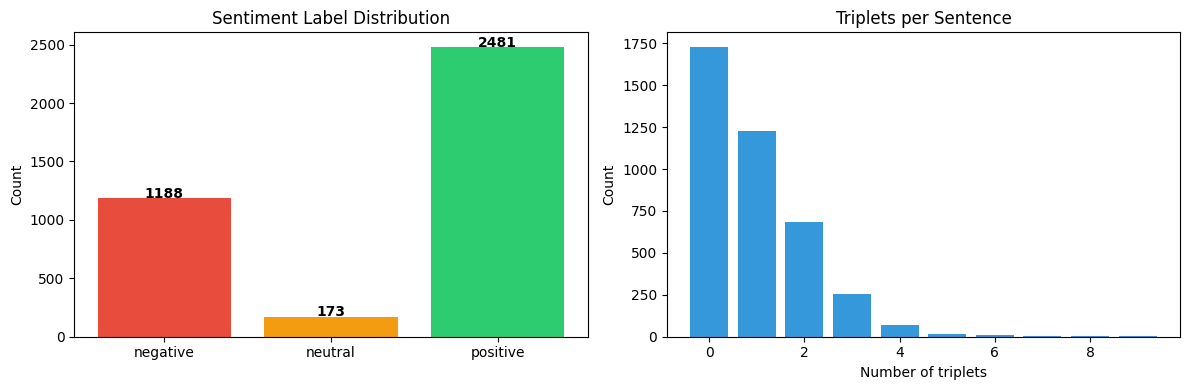

In [5]:
# Phân phối sentiment labels
all_triplets = [t for triplets in df['triplets_parsed'] for t in triplets]
sentiments = [int(t[2]) for t in all_triplets if len(t) >= 3]
sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

sentiment_counts = Counter(sentiments)
print(f'Tổng số triplets: {len(all_triplets)}')
print(f'\nPhân phối sentiment:')
for k, v in sorted(sentiment_counts.items()):
    print(f'  {k} ({sentiment_map.get(k, k)}): {v} ({v/len(sentiments)*100:.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [sentiment_map.get(k, str(k)) for k in sorted(sentiment_counts.keys())]
counts = [sentiment_counts[k] for k in sorted(sentiment_counts.keys())]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(labels, counts, color=colors[:len(labels)])
axes[0].set_title('Sentiment Label Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

triplet_dist = df['n_triplets'].value_counts().sort_index()
axes[1].bar(triplet_dist.index, triplet_dist.values, color='#3498db')
axes[1].set_title('Triplets per Sentence')
axes[1].set_xlabel('Number of triplets')
axes[1].set_ylabel('Count')

plt.tight_layout()
# plt.savefig('../outputs/reports/eda_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Top aspect terms
aspects = [t[0].lower().strip() for t in all_triplets if len(t) >= 1]
top_aspects = Counter(aspects).most_common(20)

print('Top 20 aspect terms:')
for aspect, count in top_aspects:
    print(f"  '{aspect}': {count}")

Top 20 aspect terms:
  'game': 155
  'book': 92
  'story': 73
  'app': 62
  'price': 49
  'it': 49
  'quality': 44
  'sound': 40
  'characters': 38
  'sound quality': 25
  'colors': 24
  'value': 22
  'battery': 21
  'color': 21
  'series': 20
  'cable': 19
  'books': 18
  'ink': 18
  'program': 18
  'fit': 17


In [7]:
# Flatten triplets
rows = []
for _, row in df.iterrows():
    for triplet in row['triplets_parsed']:
        if len(triplet) < 3:
            continue
        aspect, opinion, sentiment = triplet[0], triplet[1], triplet[2]
        rows.append({
            'parent_asin': row['parent_asin'],
            'sentence_text': row['sentence_text'],
            'aspect': str(aspect).lower().strip(),
            'opinion': str(opinion).lower().strip(),
            'sentiment': int(sentiment),
        })

df_asc = pd.DataFrame(rows)

# Cũng clean tag trong aspect và opinion
df_asc['aspect'] = df_asc['aspect'].apply(clean_text)
df_asc['opinion'] = df_asc['opinion'].apply(clean_text)

# Giữ nguyên 3 class
label_names = ['negative', 'neutral', 'positive']
num_labels = 3

df_asc['sentiment_label'] = df_asc['sentiment'].map({i: l for i, l in enumerate(label_names)})
df_asc['input_text'] = df_asc['sentence_text'] + ' [SEP] ' + df_asc['aspect']

print(f'Số rows sau flatten: {len(df_asc)}')
print(f'Số class: {num_labels} — {label_names}')
print(f'\nPhân phối sentiment:')
print(df_asc['sentiment_label'].value_counts())
df_asc.head(5)

Số rows sau flatten: 3842
Số class: 3 — ['negative', 'neutral', 'positive']

Phân phối sentiment:
sentiment_label
positive    2481
negative    1188
neutral      173
Name: count, dtype: int64


,parent_asin,sentence_text,aspect,opinion,sentiment,sentiment_label,input_text
0,B07DGRVTWF,basically a poor implementation of the alexa p...,alexa platform,poor implementation,0,negative,basically a poor implementation of the alexa p...
1,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,great,2,positive,support through direct messaging was great no ...
2,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,no language barrier,2,positive,support through direct messaging was great no ...
3,B07BFPJ6VX,support through direct messaging was great no ...,support through direct messaging,very responsive,2,positive,support through direct messaging was great no ...
4,B00G6SQJ46,i like this ipad cover i like this ipad cover,ipad cover,like,2,positive,i like this ipad cover i like this ipad cover ...


In [8]:
from sklearn.model_selection import train_test_split

df_with_triplets = df[df['n_triplets'] > 0].copy()

def majority_sentiment(triplets):
    labels = [int(t[2]) for t in triplets if len(t) >= 3]
    return max(set(labels), key=labels.count) if labels else 2

df_with_triplets['majority_sentiment'] = df_with_triplets['triplets_parsed'].apply(majority_sentiment)

trainval_sents, test_sents = train_test_split(
    df_with_triplets,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=df_with_triplets['majority_sentiment'],
)

train_sents, val_sents = train_test_split(
    trainval_sents,
    test_size=0.111,
    random_state=42,
    shuffle=True,
    stratify=trainval_sents['majority_sentiment'],
)

print(f'T?ng c?u c? triplets: {len(df_with_triplets)}')
print(f'  C?u train: {len(train_sents)} | C?u val: {len(val_sents)} | C?u test: {len(test_sents)}')
print('Split: sentence-level, test_size=0.10, random_state=42, shuffle=True')


T?ng c?u c? triplets: 2271
  C?u train: 1816 | C?u val: 227 | C?u test: 228
Split: sentence-level, test_size=0.10, random_state=42, shuffle=True


In [9]:
def flatten_sentences(df_sents):
    rows = []
    for _, row in df_sents.iterrows():
        for triplet in row['triplets_parsed']:
            if len(triplet) < 3:
                continue
            aspect, opinion, sentiment = triplet[0], triplet[1], int(triplet[2])
            rows.append({
                'parent_asin':   row['parent_asin'],
                'sentence_text': row['sentence_text'],
                'aspect':        clean_text(str(aspect).lower().strip()),
                'opinion':       clean_text(str(opinion).lower().strip()),
                'sentiment':     sentiment,
            })
    result = pd.DataFrame(rows)
    result['sentiment_label'] = result['sentiment'].map({i: l for i, l in enumerate(label_names)})
    result['input_text'] = result['sentence_text'] + ' [SEP] ' + result['aspect']
    return result

train_df = flatten_sentences(train_sents)
val_df   = flatten_sentences(val_sents)
test_df  = flatten_sentences(test_sents)

print(f'Sau flatten:')
print(f'  Triplets train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}')
print(f'\nPhân phối sentiment trong TRAIN:')
print(train_df['sentiment_label'].value_counts())
print(f'\nPhân phối sentiment trong VAL:')
print(val_df['sentiment_label'].value_counts())
print(f'\nPhân phối sentiment trong TEST:')
print(test_df['sentiment_label'].value_counts())

Sau flatten:
  Triplets train: 3060 | val: 388 | test: 394

Phân phối sentiment trong TRAIN:
sentiment_label
positive    1973
negative     948
neutral      139
Name: count, dtype: int64

Phân phối sentiment trong VAL:
sentiment_label
positive    255
negative    118
neutral      15
Name: count, dtype: int64

Phân phối sentiment trong TEST:
sentiment_label
positive    253
negative    122
neutral      19
Name: count, dtype: int64


In [10]:
import os
os.makedirs('../outputs/reports', exist_ok=True)

try:
    train_df.to_parquet('../outputs/asc_train.parquet', index=False)
    test_df.to_parquet('../outputs/asc_test.parquet', index=False)
    print('Saved ASC train/test parquet files.')
except PermissionError as e:
    print(f'Skip saving parquet because output file is locked: {e}')


Saved ASC train/test parquet files.


In [11]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline as SkPipeline

TOKEN_RE = re.compile(r"\b\w+(?:'\w+)?\b")

def tokenize_with_spans(text):
    return [(m.group(0), m.start(), m.end()) for m in TOKEN_RE.finditer(str(text))]

def normalize_aspect(text):
    text = clean_text(str(text).lower())
    text = re.sub(r'[^a-z0-9\s]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def token_labels_for_sentence(sentence, triplets):
    tokens = tokenize_with_spans(sentence)
    labels = ['O'] * len(tokens)
    token_norm = [normalize_aspect(tok) for tok, _, _ in tokens]

    for triplet in triplets:
        if len(triplet) < 1:
            continue
        aspect_tokens = [t for t in normalize_aspect(triplet[0]).split() if t]
        if not aspect_tokens:
            continue
        n = len(aspect_tokens)
        for i in range(0, len(token_norm) - n + 1):
            if token_norm[i:i+n] == aspect_tokens:
                labels[i] = 'B-ASP'
                for j in range(i + 1, i + n):
                    labels[j] = 'I-ASP'
                break
    return tokens, labels

def token_features(tokens, i):
    tok = tokens[i][0]
    low = tok.lower()
    prev_tok = tokens[i-1][0].lower() if i > 0 else '<BOS>'
    next_tok = tokens[i+1][0].lower() if i + 1 < len(tokens) else '<EOS>'
    return {
        'bias': 1,
        'lower': low,
        'prev': prev_tok,
        'next': next_tok,
        'prefix3': low[:3],
        'suffix3': low[-3:],
        'is_title': tok.istitle(),
        'is_digit': tok.isdigit(),
        'position_bin': min(i // 5, 10),
    }

def build_ate_training_rows(df_sents):
    X, y = [], []
    for _, row in df_sents.iterrows():
        tokens, labels = token_labels_for_sentence(row['sentence_text'], row['triplets_parsed'])
        for i in range(len(tokens)):
            X.append(token_features(tokens, i))
            y.append(labels[i])
    return X, y

X_ate_train, y_ate_train = build_ate_training_rows(train_sents)

ate_pipeline = SkPipeline([
    ('vec', DictVectorizer()),
    ('clf', SGDClassifier(
        loss='log_loss',
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        tol=1e-3,
    )),
])

ate_pipeline.fit(X_ate_train, y_ate_train)
print(f'ATE training tokens: {len(X_ate_train)}')
print(f'ATE labels: {Counter(y_ate_train)}')


ATE training tokens: 28277
ATE labels: Counter({'O': 24863, 'B-ASP': 2482, 'I-ASP': 932})


In [12]:
def predict_aspects(sentence):
    tokens = tokenize_with_spans(sentence)
    if not tokens:
        return []
    feats = [token_features(tokens, i) for i in range(len(tokens))]
    labels = ate_pipeline.predict(feats)

    aspects = []
    current = []
    for (tok, _, _), label in zip(tokens, labels):
        if label == 'B-ASP':
            if current:
                aspects.append(' '.join(current))
            current = [tok]
        elif label == 'I-ASP' and current:
            current.append(tok)
        else:
            if current:
                aspects.append(' '.join(current))
                current = []
    if current:
        aspects.append(' '.join(current))

    seen = set()
    unique = []
    for asp in aspects:
        norm = normalize_aspect(asp)
        if norm and norm not in seen:
            seen.add(norm)
            unique.append(norm)
    return unique

def gold_aspects(row):
    return sorted({normalize_aspect(t[0]) for t in row['triplets_parsed'] if len(t) >= 1 and normalize_aspect(t[0])})

def evaluate_ate(df_sents):
    tp = fp = fn = 0
    examples = []
    for _, row in df_sents.iterrows():
        gold = set(gold_aspects(row))
        pred = set(predict_aspects(row['sentence_text']))
        tp += len(gold & pred)
        fp += len(pred - gold)
        fn += len(gold - pred)
        if len(examples) < 5 and pred:
            examples.append((row['sentence_text'], sorted(gold), sorted(pred)))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn, 'examples': examples}

ate_test_metrics = evaluate_ate(test_sents)
print('ATE on test:')
print({k: round(v, 4) if isinstance(v, float) else v for k, v in ate_test_metrics.items() if k != 'examples'})
print('\n Ví dụ predicted aspects:')
for sent, gold, pred in ate_test_metrics['examples']:
    print(f'- Sentence: {sent[:100]}')
    print(f'  Gold: {gold}')
    print(f'  Pred: {pred}')


ATE on test:
{'precision': 0.5705, 'recall': 0.5652, 'f1': 0.5679, 'tp': 182, 'fp': 137, 'fn': 140}

 Ví dụ predicted aspects:
- Sentence: reading about the struggles the emotions associated are vivid and powerful
  Gold: ['emotions', 'struggles']
  Pred: ['emotions', 'reading', 'struggles']
- Sentence: their chemistry was hot
  Gold: ['chemistry']
  Pred: ['chemistry']
- Sentence: lowend frequency response is terrible
  Gold: ['lowend frequency response']
  Pred: ['response']
- Sentence: easy setup i recently purchased the thin hdtv antennas to cut the cord on of my tvs
  Gold: ['setup']
  Pred: ['cord', 'setup']
- Sentence: alexis abbott did a great job developing the characters
  Gold: ['characters']
  Pred: ['abbott', 'alexis', 'characters']


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, accuracy_score

analyzer = SentimentIntensityAnalyzer()

def vader_predict(row):
    sentence = row['sentence_text']
    aspect = row['aspect']
    idx = sentence.lower().find(aspect.lower())
    if idx >= 0:
        start = max(0, idx - 60)
        end = min(len(sentence), idx + len(aspect) + 60)
        context = sentence[start:end]
    else:
        context = sentence
    compound = analyzer.polarity_scores(context)['compound']
    if num_labels == 2:
        return 1 if compound >= 0.05 else 0
    else:
        if compound >= 0.05:
            return 2
        elif compound <= -0.05:
            return 0
        else:
            return 1

test_df['pred_vader'] = test_df.apply(vader_predict, axis=1)
y_true = test_df['sentiment']
y_pred_vader = test_df['pred_vader']

print('VADER Baseline:')
print(f'Accuracy: {accuracy_score(y_true, y_pred_vader):.4f}')
print(classification_report(y_true, y_pred_vader, target_names=label_names))

VADER Baseline:
Accuracy: 0.6802
              precision    recall  f1-score   support

    negative       0.72      0.40      0.52       122
     neutral       0.07      0.26      0.12        19
    positive       0.83      0.85      0.84       253

    accuracy                           0.68       394
   macro avg       0.54      0.50      0.49       394
weighted avg       0.76      0.68      0.70       394



In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier

X_train = train_df['input_text']
y_train = train_df['sentiment']
X_test  = test_df['input_text']

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000, sublinear_tf=True)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Scalable baseline: HashingVectorizer kh?ng c?n fit vocabulary, SGDClassifier h? tr? h?c theo batch/streaming.
sgd_pipeline = Pipeline([
    ('hashing', HashingVectorizer(ngram_range=(1, 2), n_features=2**18, alternate_sign=False, norm='l2')),
    ('clf', SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42, max_iter=1000, tol=1e-3))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
test_df['pred_lr'] = y_pred_lr

sgd_pipeline.fit(X_train, y_train)
y_pred_sgd = sgd_pipeline.predict(X_test)
test_df['pred_sgd'] = y_pred_sgd

print('TF-IDF + Logistic Regression (gold aspect ASC):')
print(f'Accuracy: {accuracy_score(y_true, y_pred_lr):.4f}')
print(classification_report(y_true, y_pred_lr, target_names=label_names))

print()
print('HashingVectorizer + SGDClassifier (gold aspect ASC, scalable):')
print(f'Accuracy: {accuracy_score(y_true, y_pred_sgd):.4f}')
print(classification_report(y_true, y_pred_sgd, target_names=label_names))


TF-IDF + Logistic Regression (gold aspect ASC):
Accuracy: 0.7386
              precision    recall  f1-score   support

    negative       0.60      0.71      0.65       122
     neutral       0.25      0.05      0.09        19
    positive       0.83      0.80      0.82       253

    accuracy                           0.74       394
   macro avg       0.56      0.52      0.52       394
weighted avg       0.73      0.74      0.73       394


HashingVectorizer + SGDClassifier (gold aspect ASC, scalable):
Accuracy: 0.7208
              precision    recall  f1-score   support

    negative       0.59      0.54      0.57       122
     neutral       0.00      0.00      0.00        19
    positive       0.78      0.86      0.82       253

    accuracy                           0.72       394
   macro avg       0.46      0.47      0.46       394
weighted avg       0.68      0.72      0.70       394



In [15]:
def gold_aspect_sentiment_pairs(row):
    pairs = set()
    for triplet in row['triplets_parsed']:
        if len(triplet) >= 3:
            aspect = normalize_aspect(triplet[0])
            if aspect:
                pairs.add((aspect, int(triplet[2])))
    return pairs

def predict_end_to_end_pairs(df_sents, sentiment_model):
    predictions = []
    for _, row in df_sents.iterrows():
        sentence = row['sentence_text']
        aspects = predict_aspects(sentence)
        pairs = set()
        for aspect in aspects:
            input_text = sentence + ' [SEP] ' + aspect
            sentiment = int(sentiment_model.predict([input_text])[0])
            pairs.add((normalize_aspect(aspect), sentiment))
        predictions.append(pairs)
    return predictions

def evaluate_pair_sets(gold_sets, pred_sets):
    tp = fp = fn = 0
    for gold, pred in zip(gold_sets, pred_sets):
        tp += len(gold & pred)
        fp += len(pred - gold)
        fn += len(gold - pred)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}

gold_e2e = [gold_aspect_sentiment_pairs(row) for _, row in test_sents.iterrows()]
pred_e2e_sgd = predict_end_to_end_pairs(test_sents, sgd_pipeline)
e2e_sgd_metrics = evaluate_pair_sets(gold_e2e, pred_e2e_sgd)

print('End-to-end ATE + Hashing/SGD, aspect+sentiment pair level:')
print({k: round(v, 4) if isinstance(v, float) else v for k, v in e2e_sgd_metrics.items()})

print('\nV? d? output end-to-end:')
shown = 0
for (_, row), gold, pred in zip(test_sents.iterrows(), gold_e2e, pred_e2e_sgd):
    if pred and shown < 5:
        print(f'- Sentence: {row["sentence_text"][:100]}')
        print(f'  Gold pairs: {sorted(gold)}')
        print(f'  Pred pairs: {sorted(pred)}')
        shown += 1


End-to-end ATE + Hashing/SGD, aspect+sentiment pair level:
{'precision': 0.4263, 'recall': 0.4084, 'f1': 0.4172, 'tp': 136, 'fp': 183, 'fn': 197}

V? d? output end-to-end:
- Sentence: reading about the struggles the emotions associated are vivid and powerful
  Gold pairs: [('emotions', 2), ('struggles', 2)]
  Pred pairs: [('emotions', 2), ('reading', 2), ('struggles', 2)]
- Sentence: their chemistry was hot
  Gold pairs: [('chemistry', 2)]
  Pred pairs: [('chemistry', 2)]
- Sentence: lowend frequency response is terrible
  Gold pairs: [('lowend frequency response', 0)]
  Pred pairs: [('response', 0)]
- Sentence: easy setup i recently purchased the thin hdtv antennas to cut the cord on of my tvs
  Gold pairs: [('setup', 2)]
  Pred pairs: [('cord', 2), ('setup', 2)]
- Sentence: alexis abbott did a great job developing the characters
  Gold pairs: [('characters', 2)]
  Pred pairs: [('abbott', 2), ('alexis', 2), ('characters', 2)]


In [16]:
import torch
import numpy as np
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

MODEL_NAME = 'microsoft/deberta-v3-base'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

model = model.float()

print(f'\nLoaded: {MODEL_NAME} (num_labels={num_labels})')


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight        


Loaded: microsoft/deberta-v3-base (num_labels=3)


In [17]:
# Tokenize
def tokenize_fn(examples):
    return tokenizer(
        examples['input_text'],
        truncation=True,
        padding='max_length',
        max_length=256
    )

train_dataset = Dataset.from_pandas(train_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))
val_dataset   = Dataset.from_pandas(val_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))
test_dataset  = Dataset.from_pandas(test_df[['input_text', 'sentiment']].rename(columns={'sentiment': 'label'}))

train_dataset = train_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])
val_dataset   = val_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])
test_dataset  = test_dataset.map(tokenize_fn, batched=True, remove_columns=['input_text'])

train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Map:   0%|          | 0/3060 [00:00<?, ? examples/s]

Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

Train: 3060 | Val: 388 | Test: 394


In [18]:
# Class weights cho imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(num_labels),
    y=train_df['sentiment'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Class weights: {dict(zip(label_names, class_weights.round(3)))}')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
    }

Class weights: {'negative': np.float64(1.076), 'neutral': np.float64(7.338), 'positive': np.float64(0.517)}


In [19]:
training_args = TrainingArguments(
    output_dir='../outputs/deberta_asc',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=20,
    fp16=False,
    bf16=False,
    report_to='none',
    save_total_limit=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.839316,0.927689,0.832474,0.553532
2,0.641090,0.928391,0.796392,0.533660
3,0.626071,0.876747,0.806701,0.625597
4,0.409046,1.141529,0.827320,0.585662
5,0.388948,1.056877,0.835052,0.669619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=960, training_loss=0.6185804421703021, metrics={'train_runtime': 1050.1571, 'train_samples_per_second': 14.569, 'train_steps_per_second': 0.914, 'total_flos': 2012853742848000.0, 'train_loss': 0.6185804421703021, 'epoch': 5.0})

In [20]:
# Evaluate DeBERTa trên test set
predictions = trainer.predict(test_dataset)
y_pred_deberta = np.argmax(predictions.predictions, axis=-1)
test_df['pred_deberta'] = y_pred_deberta

print('DeBERTa:')
print(f'Accuracy: {accuracy_score(y_true, y_pred_deberta):.4f}')
print(classification_report(y_true, y_pred_deberta, target_names=label_names))

DeBERTa:
Accuracy: 0.8756
              precision    recall  f1-score   support

    negative       0.78      0.90      0.84       122
     neutral       0.18      0.11      0.13        19
    positive       0.96      0.92      0.94       253

    accuracy                           0.88       394
   macro avg       0.64      0.64      0.64       394
weighted avg       0.87      0.88      0.87       394



In [21]:
from sklearn.metrics import f1_score, confusion_matrix

models = {
    'VADER Baseline': y_pred_vader,
    'TF-IDF + LR (gold aspect)': y_pred_lr,
    'Hashing + SGD (gold aspect)': y_pred_sgd,
}
if 'y_pred_deberta' in globals():
    models['DeBERTa (gold aspect)'] = y_pred_deberta

header = f"{'Model':<32} {'Accuracy':>10} {'F1-macro':>10}"
for name in label_names:
    header += f" {'F1-'+name:>12}"
print(header)

results_summary = {}
for name, preds in models.items():
    acc = accuracy_score(y_true, preds)
    f1m = f1_score(y_true, preds, average='macro')
    f1_per_class = f1_score(y_true, preds, average=None, labels=list(range(num_labels)), zero_division=0)
    f1_dict = {lbl: f1_per_class[i] for i, lbl in enumerate(label_names)}
    results_summary[name] = {'accuracy': acc, 'f1_macro': f1m, **{f'f1_{k}': v for k, v in f1_dict.items()}}
    row = f'{name:<32} {acc:>10.4f} {f1m:>10.4f}'
    for lbl in label_names:
        row += f' {f1_dict[lbl]:>12.4f}'
    print(row)

print()
print('End-to-end ATE + Hashing/SGD:')
print({k: round(v, 4) if isinstance(v, float) else v for k, v in e2e_sgd_metrics.items()})


Model                              Accuracy   F1-macro  F1-negative   F1-neutral  F1-positive
VADER Baseline                       0.6802     0.4893       0.5158       0.1163       0.8359
TF-IDF + LR (gold aspect)            0.7386     0.5177       0.6493       0.0870       0.8169
Hashing + SGD (gold aspect)          0.7208     0.4610       0.5665       0.0000       0.8165
DeBERTa (gold aspect)                0.8756     0.6371       0.8365       0.1333       0.9414

End-to-end ATE + Hashing/SGD:
{'precision': 0.4263, 'recall': 0.4084, 'f1': 0.4172, 'tp': 136, 'fp': 183, 'fn': 197}


In [23]:
# Error analysis cho pipeline end-to-end.
print('1 số câu test mà end-to-end chưa khớp gold pair:')
shown = 0
for (_, row), gold, pred in zip(test_sents.iterrows(), gold_e2e, pred_e2e_sgd):
    if gold != pred and shown < 10:
        print(f"Sentence: {row['sentence_text'][:120]}")
        print(f"  Gold: {sorted(gold)}")
        print(f"  Pred: {sorted(pred)}")
        print()
        shown += 1


1 số câu test mà end-to-end chưa khớp gold pair:
Sentence: reading about the struggles the emotions associated are vivid and powerful
  Gold: [('emotions', 2), ('struggles', 2)]
  Pred: [('emotions', 2), ('reading', 2), ('struggles', 2)]

Sentence: lowend frequency response is terrible
  Gold: [('lowend frequency response', 0)]
  Pred: [('response', 0)]

Sentence: easy setup i recently purchased the thin hdtv antennas to cut the cord on of my tvs
  Gold: [('setup', 2)]
  Pred: [('cord', 2), ('setup', 2)]

Sentence: alexis abbott did a great job developing the characters
  Gold: [('characters', 2)]
  Pred: [('abbott', 2), ('alexis', 2), ('characters', 2)]

Sentence: the photocopy feature is extremely easy to useplace your on the glass or feed it through the sheet feeder and press the 
  Gold: [('photocopy feature', 2)]
  Pred: [('copy button', 2), ('glass', 2), ('photocopy feature', 2)]

Sentence: beautiful puzzles only is that with the last update it has not been saving my puzzle progr